# Taller: Regresión Lineal

En este cuaderno practicaremos:

- **Carga** y **limpieza** de datos (reemplazando valores faltantes con la mediana o la moda).
- **Análisis exploratorio (EDA)** para conocer las variables.
- **Modelos de regresión lineal** simple y múltiple.
  



In [1]:
# Importamos las librerías necesarias
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Módulos para dividir datos, crear el modelo y evaluar resultados
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

# Configuración de visualización: mostrar todas las columnas y gráficos compactos
pd.set_option("display.max_columns", None)
plt.rcParams["figure.figsize"] = (6, 4)


In [2]:

# En este ejemplo, asumimos que el archivo se llama "PimaIndiansDiabetes2.csv"
csv_path = "PimaIndiansDiabetes2.csv"

# Leemos el archivo con pandas
df = pd.read_csv(csv_path)

# Mostramos dimensiones (filas x columnas) y las primeras filas
print("Dimensiones del conjunto de datos:", df.shape)
df.head()


Dimensiones del conjunto de datos: (768, 9)


,pregnant,glucose,pressure,triceps,insulin,mass,pedigree,age,diabetes
0,6,148.0,72.0,35.0,NaN,33.6,0.627,50,pos
1,1,85.0,66.0,29.0,NaN,26.6,0.351,31,neg
2,8,183.0,64.0,NaN,NaN,23.3,0.672,32,pos
3,1,89.0,66.0,23.0,94.0,28.1,0.167,21,neg
4,0,137.0,40.0,35.0,168.0,43.1,2.288,33,pos


In [3]:
# Revisamos los tipos de datos (numéricos, categóricos, etc.)
print("Tipos de datos:\n", df.dtypes)

# Contamos cuántos valores faltantes hay por columna
print("\nValores faltantes por columna:")
print(df.isna().sum())

# Vemos estadísticas básicas (solo para columnas numéricas)
df.describe()


Tipos de datos:
 pregnant      int64
glucose     float64
pressure    float64
triceps     float64
insulin     float64
mass        float64
pedigree    float64
age           int64
diabetes     object
dtype: object

Valores faltantes por columna:
pregnant      0
glucose       5
pressure     35
triceps     227
insulin     374
mass         11
pedigree      0
age           0
diabetes      0
dtype: int64


,pregnant,glucose,pressure,triceps,insulin,mass,pedigree,age
count,768.000000,763.000000,733.000000,541.000000,394.000000,757.000000,768.000000,768.000000
mean,3.845052,121.686763,72.405184,29.153420,155.548223,32.457464,0.471876,33.240885
std,3.369578,30.535641,12.382158,10.476982,118.775855,6.924988,0.331329,11.760232
min,0.000000,44.000000,24.000000,7.000000,14.000000,18.200000,0.078000,21.000000
25%,1.000000,99.000000,64.000000,22.000000,76.250000,27.500000,0.243750,24.000000
50%,3.000000,117.000000,72.000000,29.000000,125.000000,32.300000,0.372500,29.000000
75%,6.000000,141.000000,80.000000,36.000000,190.000000,36.600000,0.626250,41.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000


In [4]:
# Copiamos el DataFrame original para no modificarlo directamente
data = df.copy()

# Identificamos las columnas numéricas
num_cols = data.select_dtypes(include=[np.number]).columns.tolist()

# Reemplazamos los valores faltantes numéricos por la mediana de cada columna.
# Esto es más robusto que usar la media, pues la mediana no se ve afectada por valores extremos.
for col in num_cols:
    mediana = data[col].median(skipna=True)
    data[col] = data[col].fillna(mediana)

# Para columnas categóricas (si las hubiera), usamos el valor más frecuente (modo)
cat_cols = data.select_dtypes(exclude=[np.number]).columns.tolist()
for col in cat_cols:
    if data[col].isna().any():
        modo = data[col].mode(dropna=True)
        modo = modo.iloc[0] if not modo.empty else "desconocido"
        data[col] = data[col].fillna(modo)

# Verificamos que ya no haya valores faltantes
print("Valores faltantes restantes:", int(data.isna().sum().sum()))
data.head()


Valores faltantes restantes: 0


,pregnant,glucose,pressure,triceps,insulin,mass,pedigree,age,diabetes
0,6,148.0,72.0,35.0,125.0,33.6,0.627,50,pos
1,1,85.0,66.0,29.0,125.0,26.6,0.351,31,neg
2,8,183.0,64.0,29.0,125.0,23.3,0.672,32,pos
3,1,89.0,66.0,23.0,94.0,28.1,0.167,21,neg
4,0,137.0,40.0,35.0,168.0,43.1,2.288,33,pos


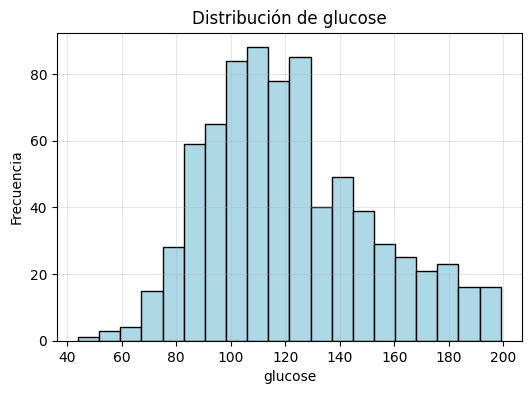

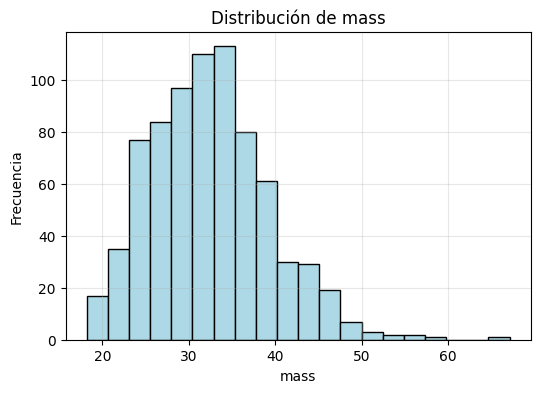

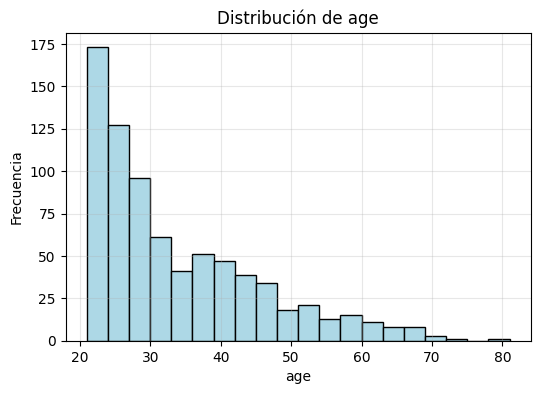

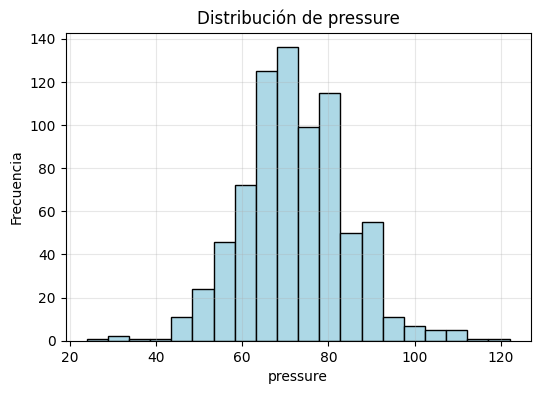

Matriz de correlación:


,pregnant,glucose,pressure,triceps,insulin,mass,pedigree,age
pregnant,1.000000,0.128213,0.208615,0.081770,0.025047,0.021559,-0.033523,0.544341
glucose,0.128213,1.000000,0.218937,0.192615,0.419451,0.231049,0.137327,0.266909
pressure,0.208615,0.218937,1.000000,0.191892,0.045363,0.281257,-0.002378,0.324915
triceps,0.081770,0.192615,0.191892,1.000000,0.155610,0.543205,0.102188,0.126107
insulin,0.025047,0.419451,0.045363,0.155610,1.000000,0.180241,0.126503,0.097101
mass,0.021559,0.231049,0.281257,0.543205,0.180241,1.000000,0.153438,0.025597
pedigree,-0.033523,0.137327,-0.002378,0.102188,0.126503,0.153438,1.000000,0.033561
age,0.544341,0.266909,0.324915,0.126107,0.097101,0.025597,0.033561,1.000000


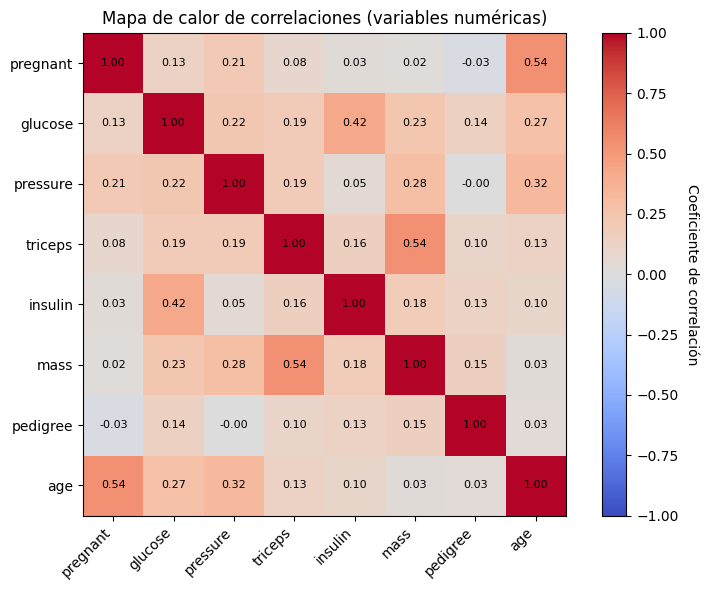

In [10]:
# ==========================================
# ANÁLISIS EXPLORATORIO DE DATOS (EDA)
# ==========================================

# 1️⃣ Visualización de distribuciones básicas
# ------------------------------------------
# Observamos cómo se distribuyen algunas variables relevantes.
cols_to_plot = [c for c in ["glucose", "mass", "age", "pressure"] if c in data.columns]

for c in cols_to_plot:
    plt.figure()
    plt.hist(data[c].dropna(), bins=20, color="lightblue", edgecolor="black")
    plt.title(f"Distribución de {c}")
    plt.xlabel(c)
    plt.ylabel("Frecuencia")
    plt.grid(alpha=0.3)
    plt.show()

# 2️⃣ Matriz de correlación numérica
# ------------------------------------------
# La correlación mide la relación lineal entre dos variables.
# Un valor cercano a 1 indica correlación positiva fuerte;
# cercano a -1, correlación negativa fuerte; y cerca de 0, sin relación lineal.

# Calculamos la matriz de correlaciones solo para variables numéricas
corr = data[num_cols].corr(numeric_only=True)

# Mostramos la matriz como tabla
print("Matriz de correlación:")
display(corr)

# 3️⃣ Mapa de calor (heatmap) de la matriz de correlación
# ------------------------------------------
# Usamos matplotlib para dibujar una cuadrícula con colores que indiquen la fuerza de la relación.

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)

# Agregamos barra de color
cbar = plt.colorbar(im)
cbar.set_label("Coeficiente de correlación", rotation=270, labelpad=15)

# Mostramos nombres de columnas y filas (índices)
ax.set_xticks(np.arange(len(num_cols)))
ax.set_yticks(np.arange(len(num_cols)))
ax.set_xticklabels(num_cols, rotation=45, ha="right")
ax.set_yticklabels(num_cols)

# 4️⃣ Escribimos los valores de correlación dentro de cada celda
# ------------------------------------------
for i in range(len(num_cols)):
    for j in range(len(num_cols)):
        valor = corr.iloc[i, j]
        ax.text(j, i, f"{valor:.2f}", ha="center", va="center", color="black", fontsize=8)

# Título y presentación
ax.set_title("Mapa de calor de correlaciones (variables numéricas)")
plt.tight_layout()
plt.show()



Coeficiente (pendiente): 1.0589187892724288
Intercepto: 87.45296712162667
R² en prueba: 0.03869994629104434
RMSE en prueba: 30.8612806202826


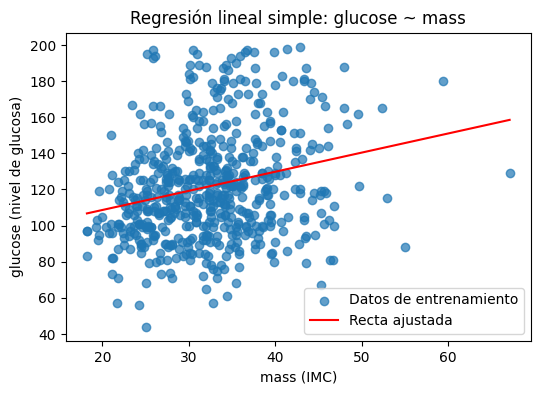

In [7]:
# Vamos a predecir el nivel de glucosa ('glucose') usando solo el índice de masa corporal ('mass')
target = "glucose"
feature = "mass"

# Comprobamos que las columnas existan
assert target in data.columns, "No se encuentra la columna 'glucose'."
assert feature in data.columns, "No se encuentra la columna 'mass'."

# Definimos las variables predictoras (X) y la variable objetivo (y)
X = data[[feature]].values
y = data[target].values

# Dividimos el conjunto de datos en entrenamiento (75%) y prueba (25%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

# Creamos el modelo de regresión lineal
lin_s = LinearRegression()

# Entrenamos el modelo con los datos de entrenamiento
lin_s.fit(X_train, y_train)

# Realizamos predicciones sobre el conjunto de prueba
y_pred = lin_s.predict(X_test)

# Evaluamos el modelo
r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred) # Removed squared=False
rmse = np.sqrt(mse) # Calculate RMSE manually

print("Coeficiente (pendiente):", lin_s.coef_[0])
print("Intercepto:", lin_s.intercept_)
print("R² en prueba:", r2)
print("RMSE en prueba:", rmse)

# Gráfico de dispersión con la línea de ajuste
plt.figure()
plt.scatter(X_train.flatten(), y_train, alpha=0.7, label="Datos de entrenamiento")
x_line = np.linspace(X.min(), X.max(), 100).reshape(-1, 1)
y_line = lin_s.predict(x_line)
plt.plot(x_line, y_line, color="red", label="Recta ajustada")
plt.title("Regresión lineal simple: glucose ~ mass")
plt.xlabel("mass (IMC)")
plt.ylabel("glucose (nivel de glucosa)")
plt.legend()
plt.show()

In [9]:
# Ahora usamos varias variables numéricas como predictoras de 'glucose'
X_cols = [c for c in num_cols if c != target]
assert len(X_cols) > 0, "No hay variables predictoras numéricas disponibles."

# Definimos X (predictoras) e y (objetivo)
X = data[X_cols].values
y = data[target].values

# División en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

# Creamos y entrenamos el modelo
lin_m = LinearRegression()
lin_m.fit(X_train, y_train)

# Predicciones y métricas
y_pred = lin_m.predict(X_test)
r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred) # Calculate MSE
rmse = np.sqrt(mse) # Calculate RMSE manually

print("R² en prueba:", r2)
print("RMSE en prueba:", rmse)

# Mostramos los coeficientes estimados
coef_df = pd.DataFrame({
    "Predictor": ["Intercepto"] + X_cols,
    "Coeficiente": [lin_m.intercept_] + list(lin_m.coef_)
})
print("\nCoeficientes del modelo múltiple:")
display(coef_df)

R² en prueba: 0.21704221775714705
RMSE en prueba: 27.851823406491516

Coeficientes del modelo múltiple:


,Predictor,Coeficiente
0,Intercepto,48.379644
1,pregnant,0.146864
2,pressure,0.239753
3,triceps,-0.186542
4,insulin,0.125925
5,mass,0.725979
6,pedigree,8.046705
7,age,0.482686


## 🧭 Conclusiones finales

Al comparar los resultados de la **regresión lineal simple** (`glucose ~ mass`) con los de la **regresión lineal múltiple**, se observa que:

- Al incluir **más variables predictoras**, el **coeficiente de determinación R²** tiende a **aumentar**.  
  Esto significa que el modelo logra explicar una **mayor proporción de la variabilidad** en los valores de glucosa.

- Sin embargo, este **incremento del R² no garantiza un mejor modelo**, ya que puede deberse a la mera inclusión de más variables, sin que aporten información verdaderamente útil.

- En este caso particular, el **dataset de Pima Indians Diabetes** fue diseñado originalmente para **clasificación** (diagnosticar presencia o ausencia de diabetes), no para predecir valores continuos como la glucosa.  
  Por ello, la **relación lineal entre las variables es débil** y el modelo no logra un ajuste satisfactorio.

- En resumen:
  - **R² mejora ligeramente** al pasar del modelo simple al múltiple.  
  - Pero **ambos modelos presentan bajo poder explicativo** y **altos errores de predicción (RMSE)**.  
  - Esto sugiere que **la regresión lineal no es el enfoque más adecuado** para estos datos.

👉 En aplicaciones reales, sería preferible explorar modelos de **clasificación** o enfoques no lineales (como árboles de decisión, regresión logística o redes neuronales), que se ajustan mejor a la naturaleza del problema.
